In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.ensemble import IsolationForest
from sklearn.linear_model import LinearRegression
import geopandas as gpd

from pathlib import Path
from warnings import simplefilter

simplefilter("ignore")  # ignore warnings to clean up output cells

In [2]:
# https://www.kaggle.com/datasets/aradhanahirapara/product-retail-price-survey-2017-2025
df = pd.read_csv("data/Retail_Prices_of_Products.csv")
df.head()

,Year,Month,GEO,Product Category,Products,VALUE,Taxable,Total tax rate,Value after tax,Essential,COORDINATE,UOM
0,2017,January,Province 1,Meat & Poultry,"Beef stewing cuts, per kilogram",12.66,No,11.0,12.66,Essential,11.10,Dollars
1,2017,January,Province 1,Meat & Poultry,"Beef striploin cuts, per kilogram",21.94,No,11.0,21.94,Essential,11.20,Dollars
2,2017,January,Province 1,Meat & Poultry,"Beef top sirloin cuts, per kilogram",13.44,No,11.0,13.44,Essential,11.30,Dollars
3,2017,January,Province 1,Meat & Poultry,"Beef rib cuts, per kilogram",20.17,No,11.0,20.17,Essential,11.41,Dollars
4,2017,January,Province 1,Meat & Poultry,"Ground beef, per kilogram",9.12,No,11.0,9.12,Essential,11.40,Dollars


In [3]:
df['Date'] = df['Month'].astype(str) + ' ' + df['Year'].astype(str)
df['Date'] = pd.to_datetime(df['Date'], format='%B %Y')
df.head()

,Year,Month,GEO,Product Category,Products,VALUE,Taxable,Total tax rate,Value after tax,Essential,COORDINATE,UOM,Date
0,2017,January,Province 1,Meat & Poultry,"Beef stewing cuts, per kilogram",12.66,No,11.0,12.66,Essential,11.10,Dollars,2017-01-01
1,2017,January,Province 1,Meat & Poultry,"Beef striploin cuts, per kilogram",21.94,No,11.0,21.94,Essential,11.20,Dollars,2017-01-01
2,2017,January,Province 1,Meat & Poultry,"Beef top sirloin cuts, per kilogram",13.44,No,11.0,13.44,Essential,11.30,Dollars,2017-01-01
3,2017,January,Province 1,Meat & Poultry,"Beef rib cuts, per kilogram",20.17,No,11.0,20.17,Essential,11.41,Dollars,2017-01-01
4,2017,January,Province 1,Meat & Poultry,"Ground beef, per kilogram",9.12,No,11.0,9.12,Essential,11.40,Dollars,2017-01-01


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 118482 entries, 0 to 118481
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Year              118482 non-null  int64         
 1   Month             118482 non-null  str           
 2   GEO               118482 non-null  str           
 3   Product Category  118482 non-null  str           
 4   Products          118482 non-null  str           
 5   VALUE             118482 non-null  float64       
 6   Taxable           118482 non-null  str           
 7   Total tax rate    118482 non-null  float64       
 8   Value after tax   118482 non-null  float64       
 9   Essential         118482 non-null  str           
 10  COORDINATE        118482 non-null  float64       
 11  UOM               118482 non-null  str           
 12  Date              118482 non-null  datetime64[us]
dtypes: datetime64[us](1), float64(4), int64(1), str(7)
memory usage: 11.8 

In [5]:
df.isnull().sum()

Year                0
Month               0
GEO                 0
Product Category    0
Products            0
VALUE               0
Taxable             0
Total tax rate      0
Value after tax     0
Essential           0
COORDINATE          0
UOM                 0
Date                0
dtype: int64

In [6]:
df['Taxable'] = df['Taxable'].astype('category')
df['Essential'] = df['Essential'].astype('category')
df['Product Category'] = df['Product Category'].astype('category')
df['GEO'] = df['GEO'].astype('category')
df = df.dropna(subset=['VALUE'])
df['Price_Level'] = pd.qcut(df['VALUE'], q=3, labels=['Low', 'Medium', 'High'])
df['Month_num'] = df['Date'].dt.month
df['Year_num'] = df['Date'].dt.year

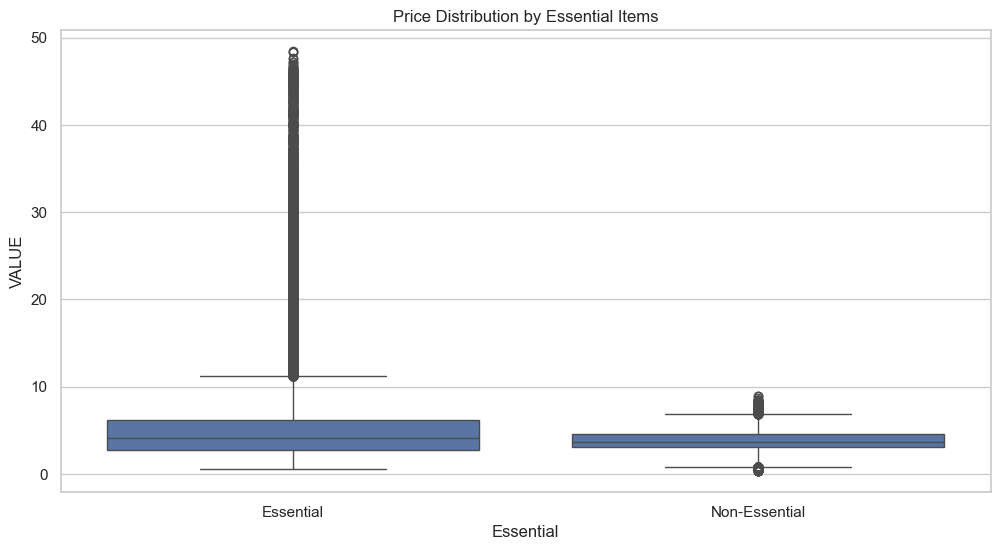

In [7]:
sns.set(style="whitegrid")
plt.figure(figsize=(12,6))
sns.boxplot(x='Essential', y='VALUE', data=df)
plt.title('Price Distribution by Essential Items')
plt.show()

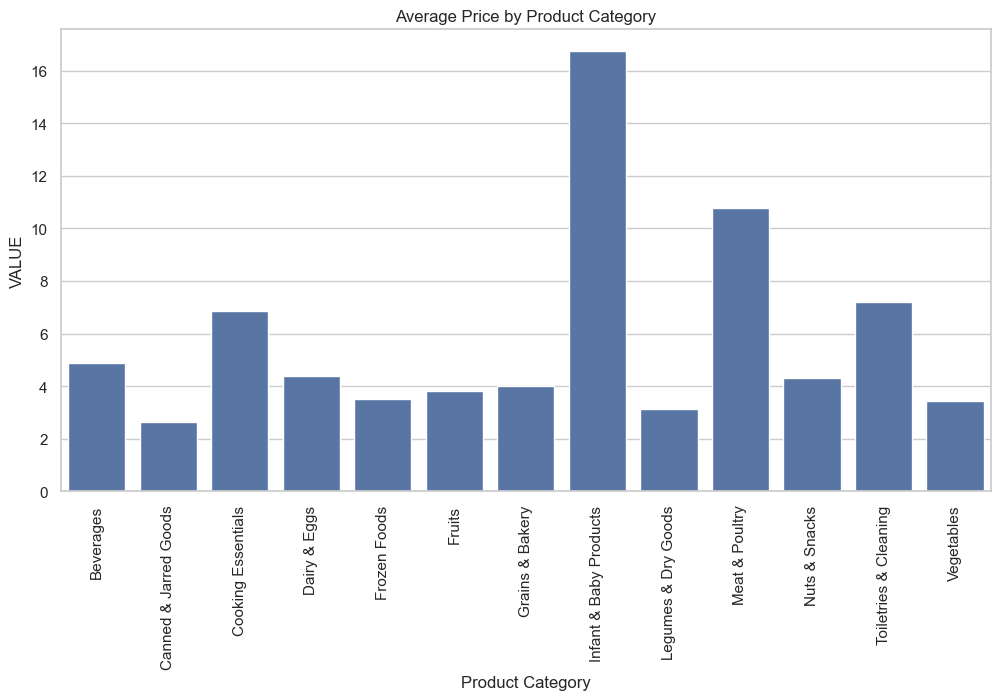

In [8]:
plt.figure(figsize=(12,6))
sns.barplot(data=df, x='Product Category', y='VALUE', ci=None)
plt.xticks(rotation=90)
plt.title('Average Price by Product Category')
plt.show()

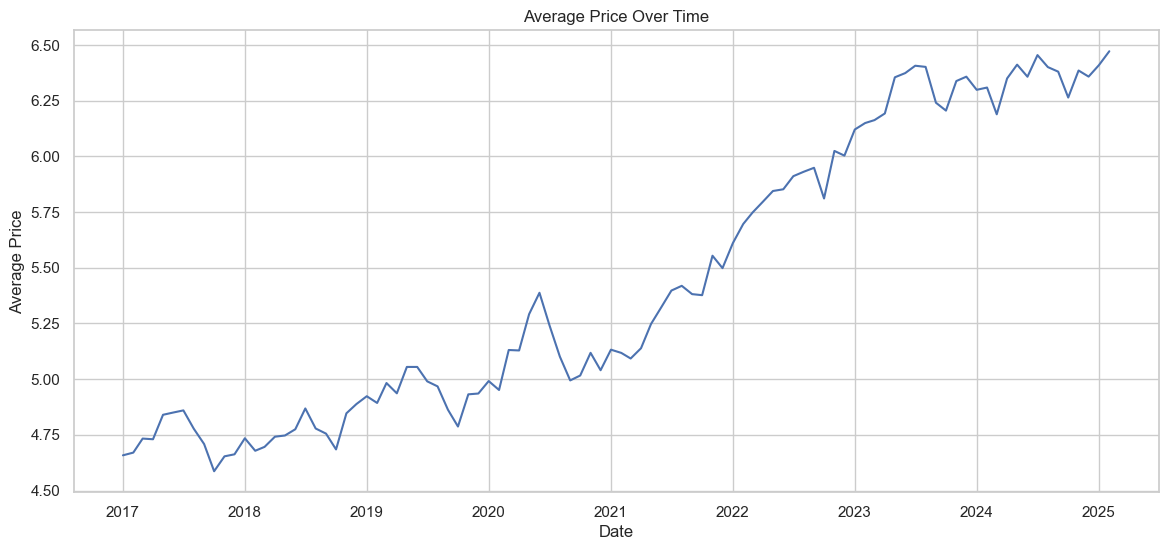

In [9]:
avg_monthly = df.groupby('Date')['VALUE'].mean().reset_index()
plt.figure(figsize=(14,6))
sns.lineplot(data=avg_monthly, x='Date', y='VALUE')
plt.title('Average Price Over Time')
plt.xlabel('Date')
plt.ylabel('Average Price')
plt.show()

In [ ]:
# linear regression model
reg_data = df[['VALUE', 'Taxable', 'Essential', 'Product Category', 'GEO', 'Month_num', 'Year_num']].copy()
reg_data = pd.get_dummies(reg_data, drop_first=True)
X_reg = reg_data.drop(columns=['VALUE'])
y_reg = reg_data['VALUE']
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)
reg_model = LinearRegression()
reg_model.fit(X_train_r, y_train_r)
y_pred_r = reg_model.predict(X_test_r)
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score
# mean_squared_error squared=True replaced by mean_squared_error
# mean_squared_error squared=False replaced by root_mean_squared_error
print("Linear Regression MSE:", mean_squared_error(y_test_r, y_pred_r))
print("Linear Regression RMSE:", root_mean_squared_error(y_test_r, y_pred_r))
print("Linear Regression R2 Score:", r2_score(y_test_r, y_pred_r))
#Linear Regression R2 Score: 0.38819888825565796 is very, we need as close to 1 as posible


Linear Regression MSE: 16.06264635184851
Linear Regression RMSE: 4.007823143783731
Linear Regression R2 Score: 0.38819888825565796


In [ ]:
# random forest model
reg_data = df[['VALUE', 'Taxable', 'Essential', 'Product Category', 'GEO', 'Month_num', 'Year_num']].copy()
reg_data = pd.get_dummies(reg_data, drop_first=True)
X_reg = reg_data.drop(columns=['VALUE'])
y_reg = reg_data['VALUE']
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)
from sklearn.ensemble import RandomForestRegressor
reg_model = RandomForestRegressor()
reg_model.fit(X_train_r, y_train_r)
y_pred_r = reg_model.predict(X_test_r)
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score
# mean_squared_error squared=True replaced by mean_squared_error
# mean_squared_error squared=False replaced by root_mean_squared_error
print("Linear Regression MSE:", mean_squared_error(y_test_r, y_pred_r))
print("Linear Regression RMSE:", root_mean_squared_error(y_test_r, y_pred_r))
print("Linear Regression R2 Score:", r2_score(y_test_r, y_pred_r))
#Linear Regression R2 Score: 0.14354872477867375 is very low, we need as close to 1 as posible


Linear Regression MSE: 22.48585968117451
Linear Regression RMSE: 4.741925735518694
Linear Regression R2 Score: 0.14354872477867375


<Axes: >

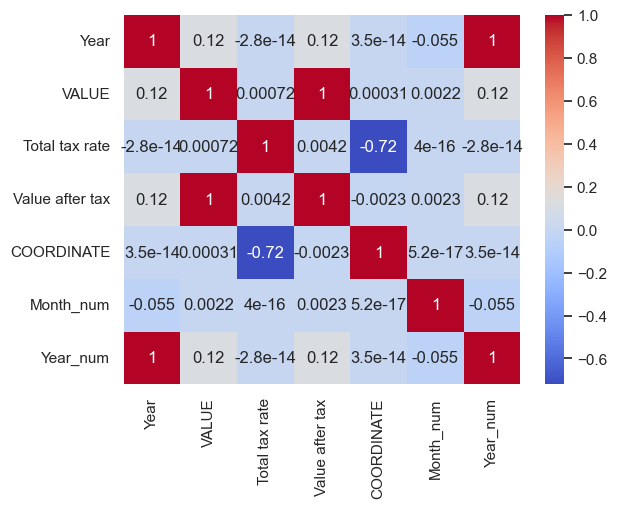

In [14]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

In [21]:
data = df

In [23]:
for col in data.columns:
    le=LabelEncoder()
    data[col]=le.fit_transform(data[col])
x=data.drop(["VALUE"],axis=1)
x=x.drop(["Value after tax"],axis=1)
y=data["VALUE"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
ss=StandardScaler()
x_train=ss.fit_transform(x_train)
x_test=ss.transform(x_test)

In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree Regression": DecisionTreeRegressor()
}
param_grid = {
    "Linear Regression": {}, 
    "Decision Tree Regression": {
        "max_depth": [3, 5, 10, None],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
    }
}
def tune_model(model, params, x_train, y_train):
    grid_search = GridSearchCV(model, param_grid=params, cv=5, scoring="r2", n_jobs=-1)
    grid_search.fit(x_train, y_train)
    return grid_search.best_estimator_
best_models = {}
for model_name, model in models.items():
    print(f"Tuning {model_name}...")
    best_models[model_name] = tune_model(model, param_grid[model_name], x_train, y_train)

Tuning Linear Regression...
Tuning Decision Tree Regression...


In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score
model_scores = {}
for model_name, model in best_models.items():
    y_pred = model.predict(x_test)
    r2 = r2_score(y_test, y_pred)
    model_scores[model_name] = r2  # Store R² Score

    print(f"\n📊 {model_name} Performance:")
    print(f"R² Score: {r2*100:.4f}")
    print(f"MAE: {mean_absolute_error(y_test, y_pred):.4f}")
    print(f"RMSE: {root_mean_squared_error(y_test, y_pred):.4f}")


📊 Linear Regression Performance:
R² Score: 25.0023
MAE: 291.1395
RMSE: 429.4542

📊 Decision Tree Regression Performance:
R² Score: 98.7859
MAE: 22.9536
RMSE: 54.6415


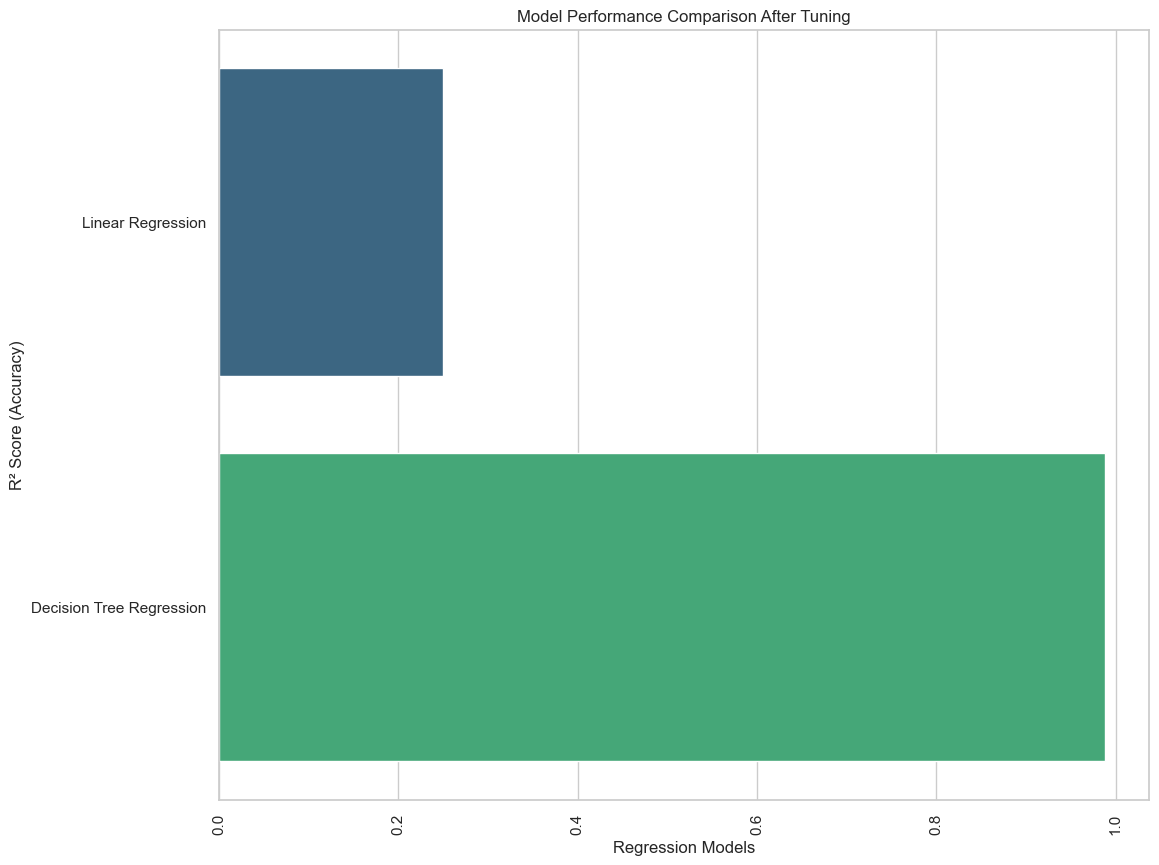

In [26]:
scores_df = pd.DataFrame(list(model_scores.items()), columns=["Model", "R² Score"])
plt.figure(figsize=(12, 10))
sns.barplot(y="Model", x="R² Score", data=scores_df, palette="viridis")
plt.xlabel("Regression Models")
plt.ylabel("R² Score (Accuracy)")
plt.title("Model Performance Comparison After Tuning")
plt.xticks(rotation=90)
plt.show()